# 🧹 Notebook 02: Data Cleaning & Engineering
**Goal:** Clean raw data, handle missing values, and prepare a master dataset.

### Steps:
1. Load all raw data
2. Remove NaN rows from air quality
3. Align all datasets to same time period
4. Resample to daily frequency
5. Merge into one master dataframe
6. Save to data/processed/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
print("✅ Libraries ready!")

✅ Libraries ready!


In [2]:
aq_df      = pd.read_csv("data/raw/kathmandu_airquality.csv", parse_dates=["datetime"])
weather_df = pd.read_csv("data/raw/kathmandu_weather.csv", parse_dates=["date"])
trends_df  = pd.read_csv("data/raw/nepal_health_trends.csv", parse_dates=["week"])

print(f"Air Quality : {aq_df.shape}")
print(f"Weather     : {weather_df.shape}")
print(f"Trends      : {trends_df.shape}")

Air Quality : (43848, 8)
Weather     : (1827, 5)
Trends      : (262, 4)


In [3]:
# Check NaN situation before cleaning
print("NaN count per column BEFORE cleaning:")
print(aq_df.isnull().sum())

# Drop rows where pm2_5 is NaN (our most important column)
aq_clean = aq_df.dropna(subset=["pm2_5"])

# Check date range after dropping
print(f"\nDate range after removing NaN:")
print(f"  From : {aq_clean['datetime'].min()}")
print(f"  To   : {aq_clean['datetime'].max()}")
print(f"  Rows : {len(aq_clean)} (removed {len(aq_df) - len(aq_clean)} NaN rows)")

NaN count per column BEFORE cleaning:
datetime                0
pm2_5               22709
pm10                22709
carbon_monoxide     22709
nitrogen_dioxide    22709
ozone               22709
dust                22709
uv_index            22709
dtype: int64

Date range after removing NaN:
  From : 2022-08-04 05:00:00
  To   : 2024-12-31 23:00:00
  Rows : 21139 (removed 22709 NaN rows)


In [4]:
# Set datetime as index for resampling
aq_clean = aq_clean.set_index("datetime")

# Resample hourly → daily averages
aq_daily = aq_clean.resample("D").agg({
    "pm2_5"           : "mean",
    "pm10"            : "mean",
    "carbon_monoxide" : "mean",
    "nitrogen_dioxide": "mean",
    "ozone"           : "mean",
    "dust"            : "mean",
    "uv_index"        : "mean"
}).reset_index()

aq_daily.rename(columns={"datetime": "date"}, inplace=True)

print(f"✅ Resampled to daily: {len(aq_daily)} days")
print(f"Date range: {aq_daily['date'].min()} → {aq_daily['date'].max()}")
print(f"\nFirst few rows:")
aq_daily.head()

✅ Resampled to daily: 881 days
Date range: 2022-08-04 00:00:00 → 2024-12-31 00:00:00

First few rows:


,date,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,ozone,dust,uv_index
0,2022-08-04,14.884211,21.226316,380.157895,14.226316,82.473684,0.0,1.547368
1,2022-08-05,18.166667,25.933333,387.916667,13.729167,82.666667,0.0,1.904167
2,2022-08-06,20.337500,29.050000,391.166667,13.262500,77.250000,0.0,1.204167
3,2022-08-07,19.170833,27.441667,463.958333,21.091667,64.291667,0.0,2.295833
4,2022-08-08,19.866667,28.416667,524.083333,23.595833,67.708333,0.0,1.710417


In [5]:
# Our air quality starts 2022-08-04 so we align everything to that
start_date = pd.Timestamp("2022-08-04")
end_date   = pd.Timestamp("2024-12-31")

# Trim air quality
aq_daily = aq_daily[
    (aq_daily["date"] >= start_date) & 
    (aq_daily["date"] <= end_date)
].reset_index(drop=True)

# Trim weather
weather_trim = weather_df[
    (weather_df["date"] >= start_date) & 
    (weather_df["date"] <= end_date)
].reset_index(drop=True)

# Trim trends (weekly — keep weeks that fall in range)
trends_trim = trends_df[
    (trends_df["week"] >= start_date) & 
    (trends_df["week"] <= end_date)
].reset_index(drop=True)

print(f"✅ Air Quality : {len(aq_daily)} days")
print(f"✅ Weather     : {len(weather_trim)} days")
print(f"✅ Trends      : {len(trends_trim)} weeks")
print(f"\nAll datasets now cover: {start_date.date()} → {end_date.date()}")

✅ Air Quality : 881 days
✅ Weather     : 881 days
✅ Trends      : 126 weeks

All datasets now cover: 2022-08-04 → 2024-12-31


## 🔗 Merging Google Trends — Linear Interpolation

Google Trends data arrives at **weekly** resolution (one value per Sunday).
To align it with the daily air quality dataset we need to bridge the 6 gap days
inside each week.

### Why not forward-fill (the original approach)?
Forward-fill (`merge_asof` with `direction='backward'`) stamps Monday's value
onto every day through Sunday — creating a **staircase** pattern:
```
Mon 44 | Tue 44 | Wed 44 | Thu 44 | Fri 44 | Sat 44 | Sun ← new week starts
```
This introduces artificial discontinuities at each week boundary and misrepresents
how search interest actually evolves (which is continuous, not step-wise).

### Better approach: linear interpolation between weekly anchors
We place the raw weekly value at the **midpoint of each week** (Wednesday),
then linearly interpolate between midpoints. This:
- Avoids the artificial step-jumps
- Doesn't claim more precision than the data actually contains
- Is transparent and reproducible

> **Epistemological note:** Neither approach recovers true daily search intent —
> Google Trends weekly values represent aggregated 7-day interest, not a point
> measurement on any single day. Interpolated values should be treated as a
> smoothed behavioural proxy, not literal daily observations.

In [6]:
# ── Step 1: Merge air quality + weather (unchanged) ────────────────────────────
master_df = pd.merge(aq_daily, weather_trim, on="date", how="left")
print(f"After merging AQ + Weather: {master_df.shape}")

# ── Step 2: Build a daily date spine and anchor Trends at week midpoints ────────
# Create a full daily index spanning the study period
daily_index = pd.date_range(start=start_date, end=end_date, freq='D')
trends_daily = pd.DataFrame({'date': daily_index})

# Rename 'week' column to 'date' for merging
trends_anchor = trends_trim.rename(columns={'week': 'date'}).copy()

# Place each weekly observation at the midpoint of that week (Wednesday = +3 days)
# This is more honest than anchoring at Monday: the weekly aggregate reflects
# the whole 7-day window, so the midpoint is the most neutral anchor.
trends_anchor['date'] = trends_anchor['date'] + pd.Timedelta(days=3)

# Merge anchors onto the daily spine
trends_daily = trends_daily.merge(trends_anchor[['date', 'cough', 'asthma']],
                                   on='date', how='left')

# ── Step 3: Linear interpolation between anchor points ─────────────────────────
trends_daily = trends_daily.set_index('date')
trends_daily['cough']  = trends_daily['cough'].interpolate(method='time')
trends_daily['asthma'] = trends_daily['asthma'].interpolate(method='time')

# Clip to valid range [0, 100] — Trends values are bounded
trends_daily['cough']  = trends_daily['cough'].clip(0, 100)
trends_daily['asthma'] = trends_daily['asthma'].clip(0, 100)

# Handle leading/trailing NaNs (before first or after last anchor) with bfill/ffill
trends_daily['cough']  = trends_daily['cough'].bfill().ffill()
trends_daily['asthma'] = trends_daily['asthma'].bfill().ffill()

trends_daily = trends_daily.reset_index()

# ── Step 4: Merge interpolated Trends onto master dataset ──────────────────────
master_df = pd.merge(master_df, trends_daily[['date', 'cough', 'asthma']],
                     on='date', how='left')

print(f"After merging Trends      : {master_df.shape}")
print(f"Missing cough  values     : {master_df['cough'].isna().sum()}")
print(f"Missing asthma values     : {master_df['asthma'].isna().sum()}")
print(f"\nFirst few rows (note smooth cough/asthma values):")
master_df[['date', 'pm2_5', 'cough', 'asthma']].head(14)

After merging AQ + Weather: (881, 12)
After merging Trends      : (881, 14)
Missing cough  values     : 0
Missing asthma values     : 0

First few rows (note smooth cough/asthma values):


,date,pm2_5,cough,asthma
0,2022-08-04,14.884211,44.000000,11.0
1,2022-08-05,18.166667,44.000000,11.0
2,2022-08-06,20.337500,44.000000,11.0
3,2022-08-07,19.170833,44.000000,11.0
4,2022-08-08,19.866667,44.000000,11.0
5,2022-08-09,17.758333,44.000000,11.0
6,2022-08-10,15.104167,44.000000,11.0
7,2022-08-11,13.791667,42.571429,11.0
8,2022-08-12,16.450000,41.142857,11.0
9,2022-08-13,23.329167,39.714286,11.0


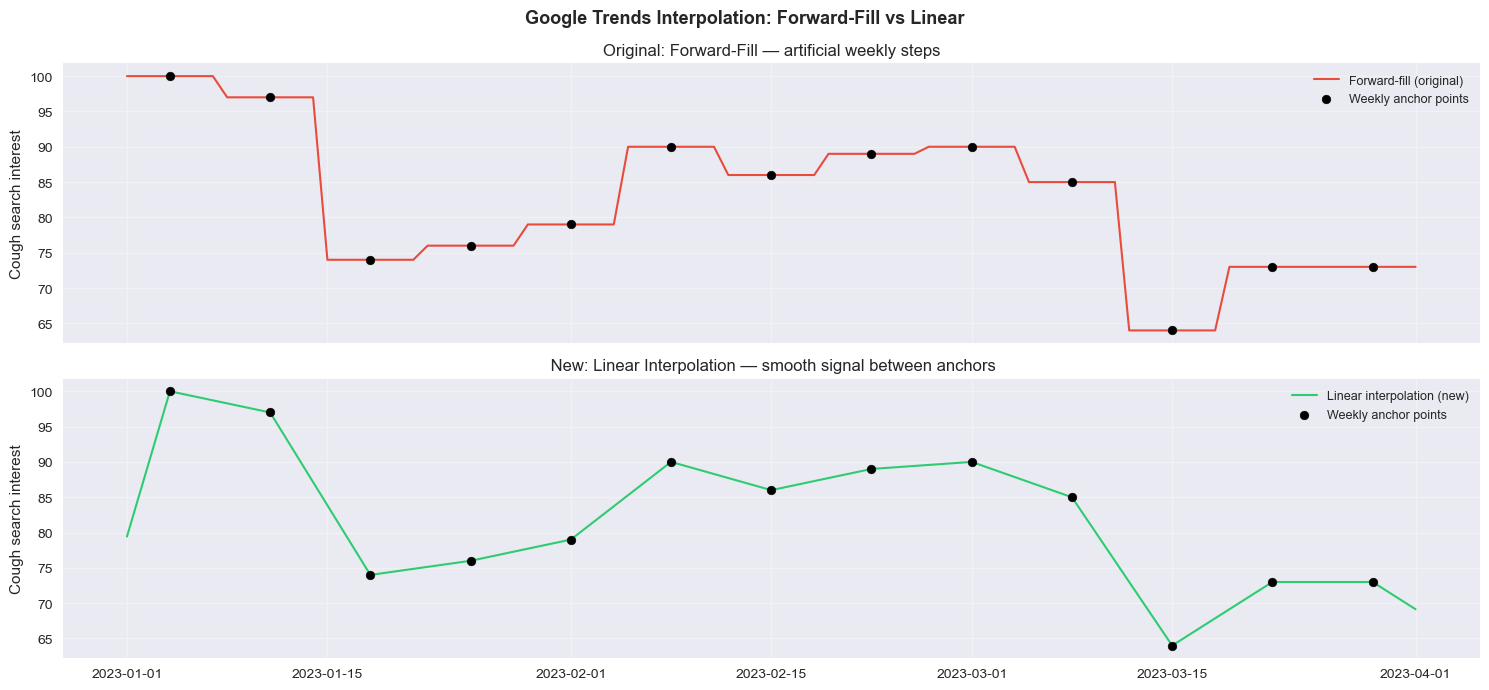


📌 The staircase pattern (top) creates artificial week-boundary jumps
   that can inflate lag-correlation coefficients at multiples of 7 days.
   Linear interpolation (bottom) avoids this artefact.


In [9]:
# ── Diagnostic plot: forward-fill vs linear interpolation ─────────────────────
# Reconstruct the old forward-fill series for visual comparison
old_trends = pd.merge_asof(
    master_df[['date']].sort_values('date'),
    trends_trim.rename(columns={'week': 'date'}).sort_values('date'),
    on='date', direction='backward'
)
old_cough = old_trends['cough'].ffill().bfill().values

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
fig.suptitle("Google Trends Interpolation: Forward-Fill vs Linear",
             fontsize=13, fontweight='bold')

# Zoom into a 3-month window to make the difference obvious
zoom_start = pd.Timestamp('2023-01-01')
zoom_end   = pd.Timestamp('2023-04-01')
mask = (master_df['date'] >= zoom_start) & (master_df['date'] <= zoom_end)
old_mask = (old_trends['date'] >= zoom_start) & (old_trends['date'] <= zoom_end)

# Weekly anchor points
anchor_mask = (trends_anchor['date'] >= zoom_start) & (trends_anchor['date'] <= zoom_end)

ax1 = axes[0]
ax1.plot(old_trends['date'][old_mask], old_cough[old_mask],
         color='#e74c3c', linewidth=1.5, label='Forward-fill (original)')
ax1.scatter(trends_anchor['date'][anchor_mask],
            trends_anchor['cough'][anchor_mask],
            color='black', s=40, zorder=5, label='Weekly anchor points')
ax1.set_title("Original: Forward-Fill — artificial weekly steps")
ax1.set_ylabel("Cough search interest")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(master_df['date'][mask], master_df['cough'][mask],
         color='#2ecc71', linewidth=1.5, label='Linear interpolation (new)')
ax2.scatter(trends_anchor['date'][anchor_mask],
            trends_anchor['cough'][anchor_mask],
            color='black', s=40, zorder=5, label='Weekly anchor points')
ax2.set_title(" New: Linear Interpolation — smooth signal between anchors")
ax2.set_ylabel("Cough search interest")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/processed/trends_interpolation_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 The staircase pattern (top) creates artificial week-boundary jumps")
print("   that can inflate lag-correlation coefficients at multiples of 7 days.")
print("   Linear interpolation (bottom) avoids this artefact.")

In [8]:
# Drop 'breathing problem' column (was all zeros — not useful)
master_df = master_df.drop(columns=['breathing problem'], errors='ignore')

# Verify
print("Missing values after cleanup:")
print(master_df.isnull().sum())
print(f"\nFinal shape: {master_df.shape}")

master_df.to_csv('data/processed/master_dataset.csv', index=False)

print("\n✅ Master dataset saved to data/processed/master_dataset.csv")
print(f"   Shape     : {master_df.shape}")
print(f"   Date range: {master_df['date'].min().date()} → {master_df['date'].max().date()}")
print(f"   Columns   : {list(master_df.columns)}")

Missing values after cleanup:
date                         0
pm2_5                        0
pm10                         0
carbon_monoxide              0
nitrogen_dioxide             0
ozone                        0
dust                         0
uv_index                     0
temperature_2m_mean          0
precipitation_sum            0
windspeed_10m_max            0
relative_humidity_2m_mean    0
cough                        0
asthma                       0
dtype: int64

Final shape: (881, 14)

✅ Master dataset saved to data/processed/master_dataset.csv
   Shape     : (881, 14)
   Date range: 2022-08-04 → 2024-12-31
   Columns   : ['date', 'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'ozone', 'dust', 'uv_index', 'temperature_2m_mean', 'precipitation_sum', 'windspeed_10m_max', 'relative_humidity_2m_mean', 'cough', 'asthma']


## ✅ Phase 2 Complete — Master Dataset Ready

| Column | Description |
|--------|-------------|
| date | Daily timestamp |
| pm2_5 | Fine particulate matter (μg/m³) |
| pm10 | Coarse particulate matter (μg/m³) |
| carbon_monoxide | CO levels |
| nitrogen_dioxide | NO2 levels |
| ozone | O3 levels |
| dust | Dust particles |
| uv_index | UV index |
| temperature_2m_mean | Mean daily temperature (°C) |
| precipitation_sum | Daily rainfall (mm) |
| windspeed_10m_max | Max wind speed (km/h) |
| relative_humidity_2m_mean | Mean humidity (%) |
| cough | Google Trends search interest |
| asthma | Google Trends search interest |

**Next: Notebook 03 — Exploratory Data Analysis & Lag Correlation**